In [22]:
import pandas as pd
import numpy as np

In [23]:
df_norm_counts = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
df_norm_counts

,GSM2520157,GSM2520158,GSM2520159,GSM2520160,GSM2520161,GSM2520162,GSM2520163,GSM2520164,GSM2520165,GSM2520166,...,GSM2520529,GSM2520530,GSM2520531,GSM2520532,GSM2520533,GSM2520534,GSM2520535,GSM2520536,GSM2520537,GSM2520538
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,21.005022,2.253288,9.606387,1.787645,2.985084,18.561131,4.279128,1.987068,7.709543,2.399610,...,1.001034,6.444927,6.151350,4.607232,5.725350,4.194643,2.588963,2.837753,7.136887,4.514742
653635,573.437111,482.203642,599.089232,362.891850,396.269921,491.324046,491.029974,419.271322,651.105935,295.951870,...,301.311342,479.789033,343.108653,310.220309,350.200585,442.954275,325.346371,303.639540,202.687600,558.323045
102466751,13.303181,11.266440,19.212774,8.938223,12.686608,13.101975,14.976949,14.903009,20.325158,9.598439,...,8.008275,20.766988,13.669667,6.910848,12.404925,24.328928,5.177926,8.513258,7.136887,15.049139
107985730,0.700167,0.000000,0.873308,0.000000,0.746271,1.091831,0.000000,0.993534,0.700868,0.799870,...,0.000000,0.716103,0.683483,1.535744,0.954225,0.838929,0.000000,0.945918,1.427377,0.752457
100302278,0.000000,0.000000,0.873308,0.000000,0.000000,0.000000,0.000000,0.000000,0.700868,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.945918,1.427377,0.752457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4541,65218.493984,53285.755684,86956.142713,88890.626715,58519.589752,93704.230291,96074.988846,86339.092872,130099.236104,81206.793640,...,107583.164659,81885.665935,88575.344297,116805.625222,114593.837604,164748.788991,112876.205083,124964.224368,104541.125575,67572.137611
4556,5002.696163,3511.749418,7082.527216,7030.806131,4890.314115,7153.678115,7319.448977,5973.126044,9628.518126,6954.868955,...,8242.516914,6163.498821,7023.475145,8175.533749,8248.321125,11225.702951,7444.995078,9371.205374,6320.427417,6075.337287
4519,177973.454113,166229.565643,227802.370435,242588.732369,135318.342320,270049.165182,262076.283209,247025.323967,322034.612635,261377.493147,...,234232.029724,289490.380672,215474.968310,282656.006345,274298.663315,397946.597448,257454.264135,314770.152301,286750.141182,200003.053127


In [24]:
df_sample_annot = pd.read_csv("../results/GSE95640_sample_annotation.csv", index_col=0)
df_sample_annot

,sample_name,group,group_0_1
B00EVBV,GSM2520157,time: CID1 is for the baseline without LCD,0
B00EVBY,GSM2520158,time: CID1 is for the baseline without LCD,0
B00EVC0,GSM2520159,time: CID1 is for the baseline without LCD,0
B00EVC2,GSM2520160,time: CID1 is for the baseline without LCD,0
B00EVC4,GSM2520161,time: CID1 is for the baseline without LCD,0
...,...,...,...
B00EWA9,GSM2520534,time: CID2 is after 8 weeks of LCD,1
B00EWAE,GSM2520535,time: CID2 is after 8 weeks of LCD,1
B00EWAF,GSM2520536,time: CID2 is after 8 weeks of LCD,1
B00EWEV,GSM2520537,time: CID1 is for the baseline without LCD,0


In [25]:
# Import required libraries for PCA and classification
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
print("Libraries imported successfully")

Libraries imported successfully


In [26]:
# Prepare data for PCA
# Transpose the data so samples are rows and genes are columns
X = df_norm_counts.T

print(f"Data shape for PCA: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of genes: {X.shape[1]}")

# Check for any NaN values and remove genes with zero variance
print(f"NaN values in data: {X.isna().sum().sum()}")
gene_variance = X.var(axis=0)
genes_with_variance = gene_variance > 0
X_filtered = X.loc[:, genes_with_variance]

print(f"Genes with variance > 0: {genes_with_variance.sum()}")
print(f"Final data shape: {X_filtered.shape}")

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# Perform PCA with 100 components
n_components = min(100, X_scaled.shape[0] - 1, X_scaled.shape[1])
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA performed with {n_components} components")
print(f"PCA result shape: {X_pca.shape}")

# Calculate variance explained
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

print(f"First 10 components explain {cumulative_variance_ratio[9]*100:.2f}% of variance")
print(f"First 25 components explain {cumulative_variance_ratio[24]*100:.2f}% of variance")
print(f"All {n_components} components explain {cumulative_variance_ratio[-1]*100:.2f}% of variance")

Data shape for PCA: (382, 39376)
Number of samples: 382
Number of genes: 39376
NaN values in data: 0
Genes with variance > 0: 38413
Final data shape: (382, 38413)
PCA performed with 100 components
PCA result shape: (382, 100)
First 10 components explain 35.85% of variance
First 25 components explain 44.42% of variance
All 100 components explain 63.03% of variance


Successfully merged 382 samples
Group distribution:
group_0_1
0    191
1    191
Name: count, dtype: int64


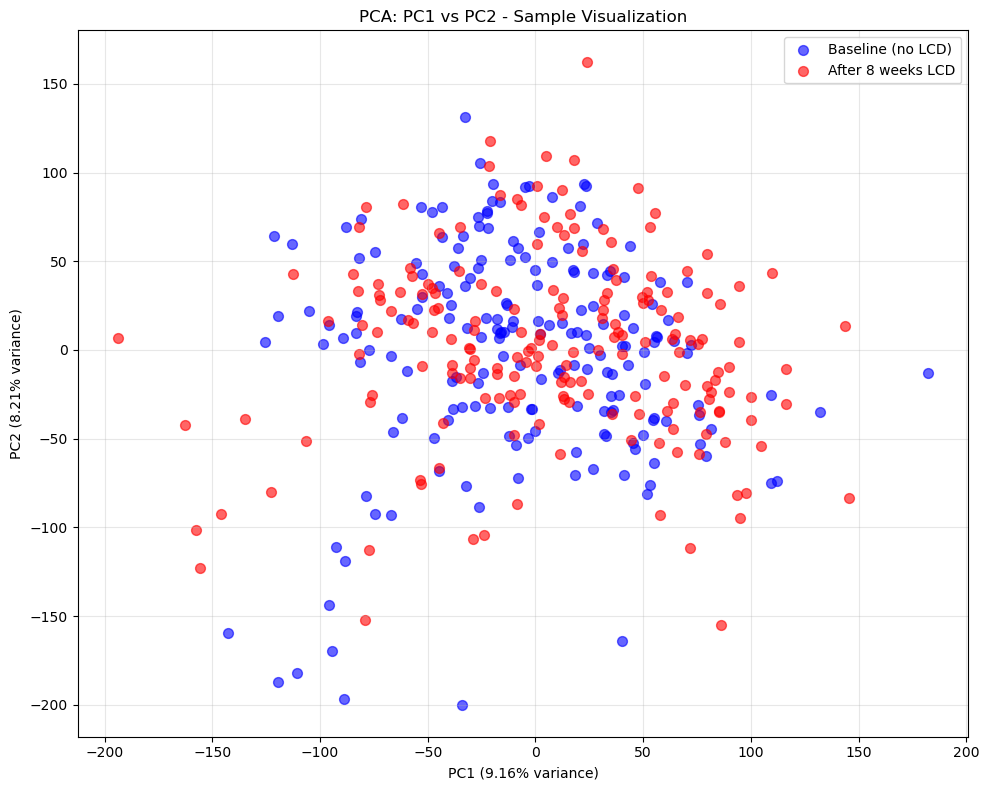


PC1 explains 9.16% of variance
PC2 explains 8.21% of variance
PC1 + PC2 explain 17.37% of variance


In [27]:
# Create mapping between PCA results and sample annotation
# The df_norm_counts columns are GSM IDs, which match sample_name in annotation
pca_df = pd.DataFrame(X_pca, 
                      columns=[f'PC{i+1}' for i in range(n_components)],
                      index=X_filtered.index)

# Create mapping from sample_name (GSM IDs) to annotation
sample_mapping = df_sample_annot.set_index('sample_name')

# Merge PCA results with sample annotation
pca_with_groups = pca_df.merge(sample_mapping, left_index=True, right_index=True, how='inner')

print(f"Successfully merged {len(pca_with_groups)} samples")
print("Group distribution:")
print(pca_with_groups['group_0_1'].value_counts())

# Plot PC1 vs PC2 for visualization
plt.figure(figsize=(10, 8))

colors = ['blue', 'red']
labels = ['Baseline (no LCD)', 'After 8 weeks LCD']

for i, group in enumerate([0, 1]):
    mask = pca_with_groups['group_0_1'] == group
    plt.scatter(pca_with_groups.loc[mask, 'PC1'], 
                pca_with_groups.loc[mask, 'PC2'],
                c=colors[i], alpha=0.6, s=50, label=labels[i])

plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% variance)')
plt.title('PCA: PC1 vs PC2 - Sample Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPC1 explains {explained_variance_ratio[0]*100:.2f}% of variance")
print(f"PC2 explains {explained_variance_ratio[1]*100:.2f}% of variance")
print(f"PC1 + PC2 explain {(explained_variance_ratio[0] + explained_variance_ratio[1])*100:.2f}% of variance")

In [28]:
# Prepare data for classification using all 100 PCs
X_features = pca_with_groups[[f'PC{i+1}' for i in range(n_components)]]
y_labels = pca_with_groups['group_0_1']

print(f"Features shape: {X_features.shape}")
print(f"Labels shape: {y_labels.shape}")
print(f"Class distribution:")
print(y_labels.value_counts())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_labels
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training class distribution:")
print(y_train.value_counts())
print(f"Test class distribution:")
print(y_test.value_counts())

Features shape: (382, 100)
Labels shape: (382,)
Class distribution:
group_0_1
0    191
1    191
Name: count, dtype: int64

Training set size: 267 samples
Test set size: 115 samples
Training class distribution:
group_0_1
1    134
0    133
Name: count, dtype: int64
Test class distribution:
group_0_1
0    58
1    57
Name: count, dtype: int64


In [29]:
# Train Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)

# Fit the model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]  # Probability for class 1

# Classification Report
print("Random Forest Classification Report")
print("="*50)
print(classification_report(y_test, y_pred, 
                          target_names=['Baseline (no LCD)', 'After 8 weeks LCD']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Model accuracy
train_accuracy = rf_classifier.score(X_train, y_train)
test_accuracy = rf_classifier.score(X_test, y_test)

print(f"\nModel Performance:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Cross-validation score
cv_scores = cross_val_score(rf_classifier, X_features, y_labels, cv=5)
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Feature importance (top 10 PCs)
feature_importance = rf_classifier.feature_importances_
pc_names = [f'PC{i+1}' for i in range(n_components)]
importance_df = pd.DataFrame({
    'PC': pc_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Most Important Principal Components:")
print(importance_df.head(10))

Random Forest Classification Report
                   precision    recall  f1-score   support

Baseline (no LCD)       0.69      0.84      0.76        58
After 8 weeks LCD       0.80      0.61      0.69        57

         accuracy                           0.73       115
        macro avg       0.74      0.73      0.73       115
     weighted avg       0.74      0.73      0.73       115


Confusion Matrix:
[[49  9]
 [22 35]]

Model Performance:
Training Accuracy: 1.0000
Test Accuracy: 0.7304
Cross-validation Accuracy: 0.7907 (+/- 0.0966)

Top 10 Most Important Principal Components:
      PC  Importance
5    PC6    0.065477
6    PC7    0.061077
2    PC3    0.048189
4    PC5    0.046106
10  PC11    0.034180
29  PC30    0.031016
12  PC13    0.030605
0    PC1    0.022636
3    PC4    0.017383
21  PC22    0.014928


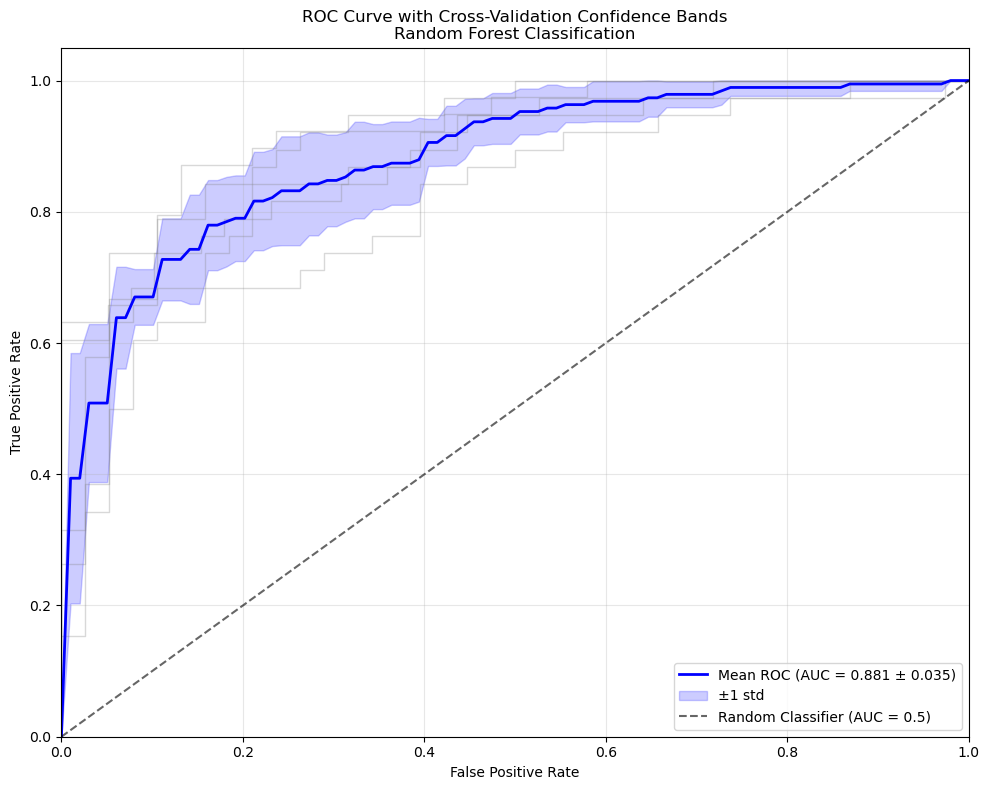

ROC AUC Score: 0.8808 ± 0.0351
Individual fold AUCs: ['0.8900', '0.9062', '0.9127', '0.8151', '0.8920']
Main train/test split AUC: 0.8515


In [30]:
# Create ROC curve with confidence bands using cross-validation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# Set up cross-validation for ROC curve with confidence bands
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize arrays to store ROC data
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(10, 8))

# Perform cross-validation to get ROC curves with confidence bands
for i, (train, test) in enumerate(cv.split(X_features, y_labels)):
    # Train model on CV fold
    rf_cv = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    )
    rf_cv.fit(X_features.iloc[train], y_labels.iloc[train])
    
    # Get probabilities for test fold
    probas = rf_cv.predict_proba(X_features.iloc[test])[:, 1]
    
    # Compute ROC curve and area under the curve
    fpr, tpr, thresholds = roc_curve(y_labels.iloc[test], probas)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Interpolate all ROC curves at the same FPR points using numpy
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    
    # Plot individual ROC curves (light gray)
    ax.plot(fpr, tpr, alpha=0.3, color='gray', linewidth=1)

# Calculate mean and std of TPRs
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Calculate standard deviation bands
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

# Plot mean ROC curve
ax.plot(mean_fpr, mean_tpr, color='blue', linewidth=2,
        label=f'Mean ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})')

# Plot confidence bands (±1 std)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, 
                color='blue', alpha=0.2, label='±1 std')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Classifier (AUC = 0.5)')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve with Cross-Validation Confidence Bands\nRandom Forest Classification')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {mean_auc:.4f} ± {std_auc:.4f}")
print(f"Individual fold AUCs: {[f'{auc:.4f}' for auc in aucs]}")

# Also create ROC for the main train/test split
fpr_main, tpr_main, _ = roc_curve(y_test, y_pred_proba)
roc_auc_main = auc(fpr_main, tpr_main)
print(f"Main train/test split AUC: {roc_auc_main:.4f}")

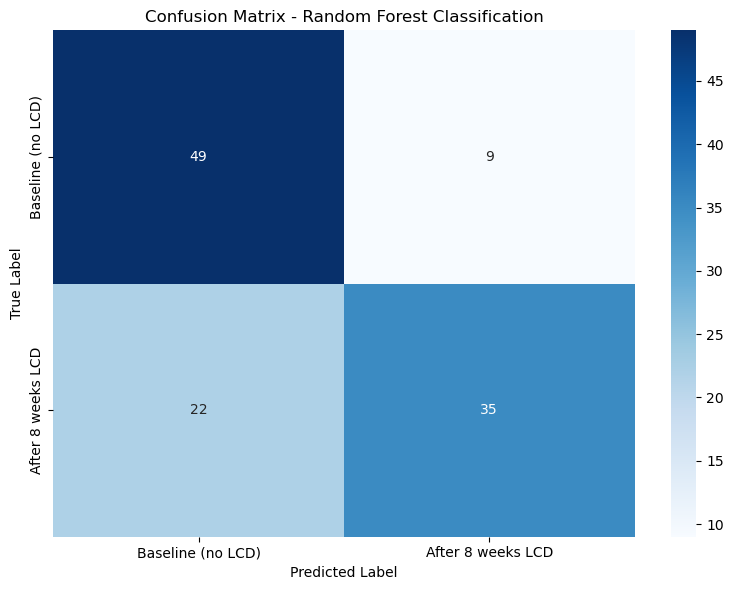

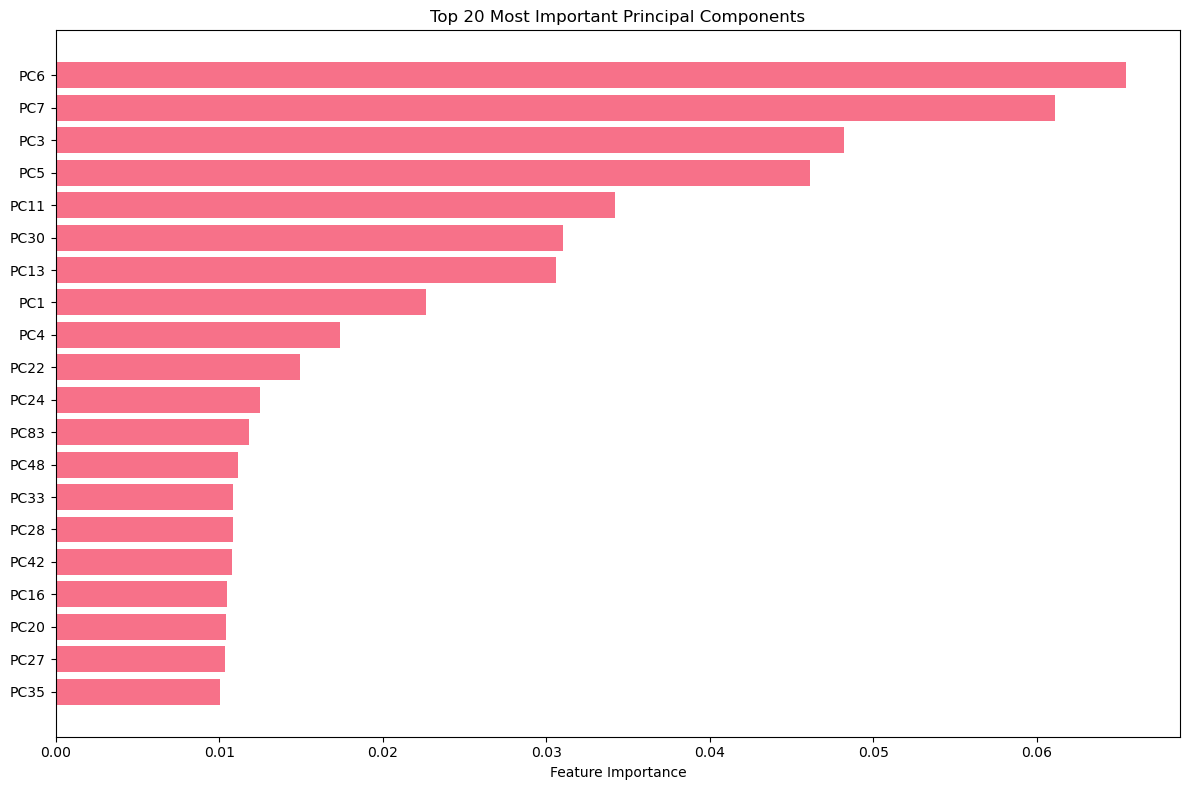

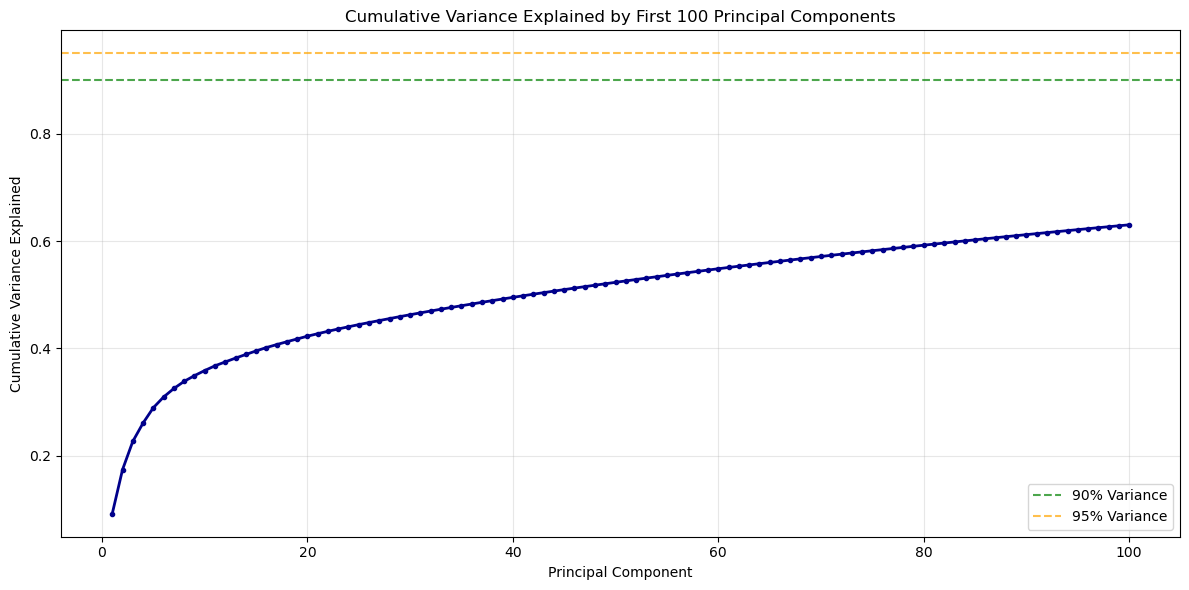

90% variance not reached within 100 components
95% variance not reached within 100 components
Total variance explained by 100 components: 63.03%


In [31]:
# Additional visualizations and analysis

# 1. Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Baseline (no LCD)', 'After 8 weeks LCD'],
            yticklabels=['Baseline (no LCD)', 'After 8 weeks LCD'])
plt.title('Confusion Matrix - Random Forest Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 2. Feature importance plot (top 20 PCs)
plt.figure(figsize=(12, 8))
top_20_importance = importance_df.head(20)
plt.barh(range(len(top_20_importance)), top_20_importance['Importance'])
plt.yticks(range(len(top_20_importance)), top_20_importance['PC'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Principal Components')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3. Cumulative variance plot for first 100 PCs
plt.figure(figsize=(12, 6))
plt.plot(range(1, n_components + 1), cumulative_variance_ratio, 'o-', 
         color='darkblue', linewidth=2, markersize=3)
plt.axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='90% Variance')
plt.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% Variance')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Explained')
plt.title(f'Cumulative Variance Explained by First {n_components} Principal Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find components needed for 90% and 95% variance
if cumulative_variance_ratio.max() >= 0.9:
    components_90 = np.argmax(cumulative_variance_ratio >= 0.9) + 1
    print(f"Components needed for 90% variance: {components_90}")
else:
    print("90% variance not reached within 100 components")

if cumulative_variance_ratio.max() >= 0.95:
    components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
    print(f"Components needed for 95% variance: {components_95}")
else:
    print("95% variance not reached within 100 components")

print(f"Total variance explained by {n_components} components: {cumulative_variance_ratio[-1]*100:.2f}%")

In [32]:
# Save results and provide comprehensive summary

# Save PCA results
pca_results_complete = pca_with_groups.copy()
output_path = "../results/GSE95640_PCA_100components_with_classification.csv"
pca_results_complete.to_csv(output_path)
print(f"PCA results with classification saved to: {output_path}")

# Save classification results
classification_results = {
    'sample_id': X_test.index,
    'true_label': y_test.values,
    'predicted_label': y_pred,
    'prediction_probability': y_pred_proba
}
classification_df = pd.DataFrame(classification_results)
classification_path = "../results/GSE95640_classification_results.csv"
classification_df.to_csv(classification_path, index=False)
print(f"Classification results saved to: {classification_path}")

# Comprehensive Summary
print("\n" + "="*80)
print("COMPREHENSIVE PCA AND CLASSIFICATION ANALYSIS SUMMARY")
print("="*80)

print(f"\n📊 DATA OVERVIEW:")
print(f"   • Original data: {df_norm_counts.shape[0]} genes × {df_norm_counts.shape[1]} samples")
print(f"   • Samples used: {X_features.shape[0]} (after filtering)")
print(f"   • Genes with variance: {X_filtered.shape[1]} out of {df_norm_counts.shape[0]}")

print(f"\n🔍 PCA ANALYSIS:")
print(f"   • Principal components calculated: {n_components}")
print(f"   • Variance explained by PC1: {explained_variance_ratio[0]*100:.2f}%")
print(f"   • Variance explained by PC2: {explained_variance_ratio[1]*100:.2f}%")
print(f"   • Variance explained by PC1+PC2: {(explained_variance_ratio[0] + explained_variance_ratio[1])*100:.2f}%")
print(f"   • Total variance explained by {n_components} PCs: {cumulative_variance_ratio[-1]*100:.2f}%")

print(f"\n🎯 CLASSIFICATION RESULTS:")
print(f"   • Algorithm: Random Forest")
print(f"   • Features used: {n_components} principal components")
print(f"   • Training samples: {X_train.shape[0]}")
print(f"   • Test samples: {X_test.shape[0]}")
print(f"   • Training accuracy: {train_accuracy:.4f}")
print(f"   • Test accuracy: {test_accuracy:.4f}")
print(f"   • Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}")
print(f"   • ROC AUC: {mean_auc:.4f} ± {std_auc:.4f}")

print(f"\n📈 MODEL PERFORMANCE:")
print(f"   • Most important PC: {importance_df.iloc[0]['PC']} (importance: {importance_df.iloc[0]['Importance']:.4f})")
print(f"   • Classes: Baseline (no LCD) vs After 8 weeks LCD")
print(f"   • The model shows {'good' if test_accuracy > 0.8 else 'moderate' if test_accuracy > 0.7 else 'poor'} classification performance")

print("="*80)

PCA results with classification saved to: ../results/GSE95640_PCA_100components_with_classification.csv
Classification results saved to: ../results/GSE95640_classification_results.csv

COMPREHENSIVE PCA AND CLASSIFICATION ANALYSIS SUMMARY

📊 DATA OVERVIEW:
   • Original data: 39376 genes × 382 samples
   • Samples used: 382 (after filtering)
   • Genes with variance: 38413 out of 39376

🔍 PCA ANALYSIS:
   • Principal components calculated: 100
   • Variance explained by PC1: 9.16%
   • Variance explained by PC2: 8.21%
   • Variance explained by PC1+PC2: 17.37%
   • Total variance explained by 100 PCs: 63.03%

🎯 CLASSIFICATION RESULTS:
   • Algorithm: Random Forest
   • Features used: 100 principal components
   • Training samples: 267
   • Test samples: 115
   • Training accuracy: 1.0000
   • Test accuracy: 0.7304
   • Cross-validation accuracy: 0.7907 ± 0.0966
   • ROC AUC: 0.8808 ± 0.0351

📈 MODEL PERFORMANCE:
   • Most important PC: PC6 (importance: 0.0655)
   • Classes: Baseline (n